# License Plate Detection + OCR — Full Pipeline

Run this notebook cell-by-cell with the **License Plate Project (venv)** kernel selected (kernel picker, top-right in VS Code).

This is the local, single-notebook continuation of the original Google Colab workflow. It covers everything *after* training (which stays on Colab — see `PROJECT_CONTEXT.md` for why): loading the trained model, detecting a plate, cropping it, reading the text with OCR, and running the whole thing on video with a table of results.

Engine choice: **PaddleOCR only**. EasyOCR was benchmarked against it earlier and lost decisively (exact plate match at 0.97 confidence vs. a fragmented misread) — see `PROJECT_CONTEXT.md` → "OCR Accuracy" for the numbers. Running two OCR engines every time would just double inference cost for no benefit, especially on a Pi.

**Phase 9 update:** the actual pipeline logic (detection, OCR, dedup) now lives in the `license_plate_pipeline/` package at the repo root, with a `tests/` suite (pytest) covering the pure logic against the real cases found while building this notebook. This notebook imports from that package rather than duplicating the code — it's still where you run things interactively and see the results, but the tested, reusable implementation lives in the package.

**Steps:**
1. Setup
2. Load the trained detection model
3. Detect a plate in an image
4. Crop the detected plate + preprocess for OCR
5. Load the OCR engine (PaddleOCR)
6. Read the plate text
7. Final pipeline: one function, start to finish
8. Run the pipeline on video, with dedup — outputs a table of plate + timestamp events
9. Clean the duplicates: confidence-based clustering, plus a second pass that re-merges already-finished clusters — merges OCR-flicker duplicates, keeps the highest-confidence reading, and shows exactly what got merged so you can verify it
10. Live webcam test — same pipeline on a live feed instead of a file; you run this one yourself interactively

Full project history, roadmap, and environment notes live in [`PROJECT_CONTEXT.md`](../PROJECT_CONTEXT.md) at the repo root.

## 1. Setup

In [25]:
%matplotlib inline
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO  # import before paddleocr - see PROJECT_CONTEXT.md "Import order" note

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))  # so `import license_plate_pipeline` works from notebooks/

TEST_IMAGES = PROJECT_ROOT / "test_images"
TEST_IMAGE = TEST_IMAGES / "demo2.jpg"  # US plate (California), ground truth 6FVZ747

## 2. Load the trained detection model

This is the YOLO26n model fine-tuned on Colab (25 epochs, T4 GPU) — mAP50 = 0.982, mAP50-95 = 0.694 on the validation set. Full training run and curves are in `runs/train/`.

In [26]:
from license_plate_pipeline.detection import get_model

model = get_model()
print("Model loaded. Classes:", model.names)

Model loaded. Classes: {0: 'License_Plate'}


## 3. Detect a plate in an image

Detections: 1


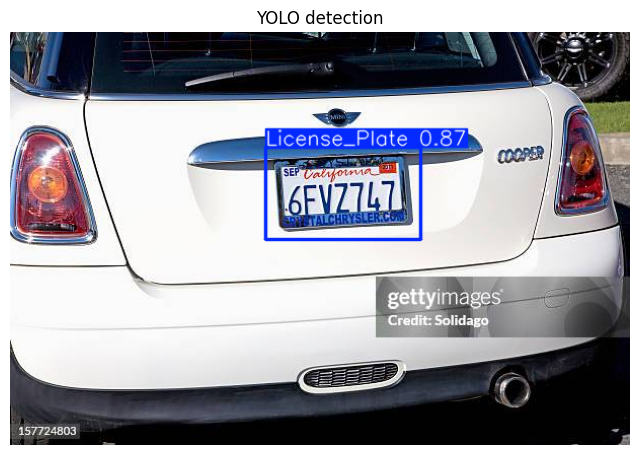

In [27]:
results = model.predict(source=str(TEST_IMAGE), save=False, verbose=False)
result = results[0]

print(f"Detections: {len(result.boxes)}")

annotated = result.plot()  # ultralytics' built-in box+label drawing
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO detection")
plt.show()

## 4. Crop the detected plate + preprocess for OCR

The raw crop feeds OCR badly (plates crop small, low contrast). Three fixes, discovered while debugging the original OCR blocker:
1. **Pad** the box 10% per side (in case edges got cut off)
2. **Upscale** 3x (`cv2.resize`, cubic interpolation) — more pixels for OCR to work with
3. **Grayscale + histogram equalization** — boosts contrast

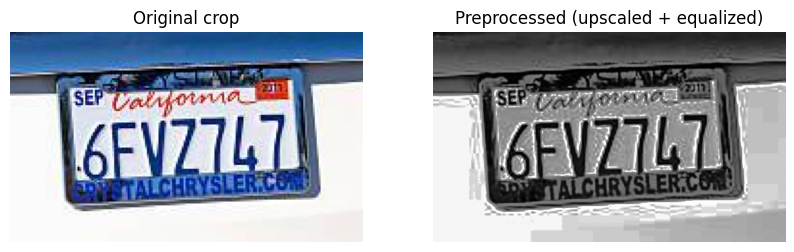

In [28]:
from license_plate_pipeline.detection import pad_box
from license_plate_pipeline.ocr import preprocess_for_ocr

img = cv2.imread(str(TEST_IMAGE))
h, w = img.shape[:2]
x1, y1, x2, y2 = map(int, result.boxes.xyxy[0])
x1, y1, x2, y2 = pad_box(x1, y1, x2, y2, w, h)
crop = img[y1:y2, x1:x2]
processed = preprocess_for_ocr(crop)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original crop")
axes[0].axis("off")
axes[1].imshow(processed, cmap="gray")
axes[1].set_title("Preprocessed (upscaled + equalized)")
axes[1].axis("off")
plt.show()

## 5. Load the OCR engine (PaddleOCR)

Runs on CPU here (this machine has no CUDA GPU — fine for dev, actual Pi inference speed will differ).

`enable_mkldnn=False`: the pretrained PP-OCR models were exported with an older PaddlePaddle version, and the newer runtime's oneDNN fused-conv path errors on them without this flag. See `PROJECT_CONTEXT.md` for the full list of environment gotchas hit getting this working.

In [29]:
from license_plate_pipeline.ocr import get_reader

paddle_reader = get_reader()
print("OCR engine loaded.")

OCR engine loaded.


## 6. Read the plate text

In [30]:
from license_plate_pipeline.ocr import read_crop

for text, confidence in read_crop(crop):
    print(f"'{text}' (confidence: {confidence:.2f})")

'SEP' (confidence: 0.99)
'6FVZ747' (confidence: 0.97)
'STALCHRYSLER.CO' (confidence: 0.95)


## 7. Final pipeline: one function, start to finish

This combines everything above — detect, crop, preprocess, OCR — into the single function the project builds on next (video frames, then dedup/tracking, then the Pi).

In [31]:
from license_plate_pipeline.detection import detect_boxes


def detect_and_read(image_path):
    img = cv2.imread(str(image_path))

    plates = []
    for x1, y1, x2, y2 in detect_boxes(img):
        crop = img[y1:y2, x1:x2]
        plates.extend(read_crop(crop))
    return plates


for text, confidence in detect_and_read(TEST_IMAGE):
    print(f"Detected plate text: '{text}' (confidence: {confidence:.2f})")

Detected plate text: 'SEP' (confidence: 0.99)
Detected plate text: '6FVZ747' (confidence: 0.97)
Detected plate text: 'STALCHRYSLER.CO' (confidence: 0.95)


## 8. Run the pipeline on video, with dedup

`demo.mp4` is 631 frames at 30fps (~21s). Running detection+OCR on every frame (timed at ~0.08s/frame detect + ~0.08s per detected box for OCR) takes roughly 2 minutes total on this CPU.

Two things need handling that single-image mode didn't:

**1. Plate crops also contain nearby text** (registration stickers, dealer frame text like `STALCHRYSLER.CO`) that PaddleOCR happily reads too. `select_plate_text` below picks the fragment that actually looks like a plate (5-8 alphanumeric characters, no punctuation) instead of just the highest-confidence fragment — otherwise a sticker or dealer-frame reading can outrank the real plate number.

**2. The same truck appears in many consecutive frames.** This is exactly the dedup problem flagged in Phase 7 of the roadmap. Approach taken here (documented in `PROJECT_CONTEXT.md` as the planned strategy): group by exact plate text, and treat a re-appearance as a **new** event only if the plate hasn't been seen for more than `GAP_SECONDS`. Each event becomes one row: first-seen timestamp, last-seen timestamp, how many frames it was seen in, and the best OCR confidence.

**Known limitation:** if OCR flickers between two different misreadings of the *same* physical plate, this exact-text grouping will (incorrectly) split it into two events. The next planned fix (Phase 7, not yet built) is confidence-based clustering: group by time overlap instead of exact text, and keep only the highest-confidence reading per cluster. For now, events seen in only 1-2 frames are filtered out below as likely noise — worth eyeballing the unfiltered `finished_events` list if a real plate seems to be missing.

The `seconds_into_video` columns stand in for what would be a real wall-clock `datetime.now()` timestamp on a live camera feed — this table's shape (plate number + first-seen + last-seen timestamps) is what will map onto the Postgres events table in Phase 10.

In [32]:
from license_plate_pipeline.pipeline import read_plates_from_frame

# read_plates_from_frame (license_plate_pipeline/pipeline.py) does what detect_and_read
# above does, but additionally filters each box's OCR fragments down to the one that
# actually looks like a plate (via select_plate_text in ocr.py) - needed because with
# many frames, sticker/dealer-text noise adds up fast. See PROJECT_CONTEXT.md "Video
# Pipeline + Dedup" for why this matters more here than in single-image mode.

In [33]:
from tqdm.auto import tqdm

from license_plate_pipeline.config import GAP_SECONDS

video_path = TEST_IMAGES / "demo.mp4"
cap = cv2.VideoCapture(str(video_path))
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

active_events = {}  # plate_text -> currently-open event dict
finished_events = []

frame_idx = 0
with tqdm(total=frame_count, desc="Processing video") as pbar:
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        timestamp = frame_idx / fps

        for text, confidence in read_plates_from_frame(frame):
            event = active_events.get(text)
            if event is not None and timestamp - event["last_seen"] <= GAP_SECONDS:
                event["last_seen"] = timestamp
                event["frame_count"] += 1
                event["best_confidence"] = max(event["best_confidence"], confidence)
            else:
                if event is not None:
                    finished_events.append(event)
                active_events[text] = {
                    "plate_text": text,
                    "first_seen": timestamp,
                    "last_seen": timestamp,
                    "best_confidence": confidence,
                    "frame_count": 1,
                }

        frame_idx += 1
        pbar.update(1)

cap.release()
finished_events.extend(active_events.values())
finished_events.sort(key=lambda e: e["first_seen"])

print(f"Raw events (before noise filtering): {len(finished_events)}")


Processing video:   0%|          | 0/631 [00:00<?, ?it/s]

Raw events (before noise filtering): 71


In [34]:
import pandas as pd

from license_plate_pipeline.config import MIN_FRAMES

df = pd.DataFrame(finished_events)
df["seconds_into_video_first"] = df["first_seen"].round(2)
df["seconds_into_video_last"] = df["last_seen"].round(2)

events_table = (
    df[df["frame_count"] >= MIN_FRAMES]
    .sort_values("seconds_into_video_first")
    .reset_index(drop=True)[
        ["plate_text", "seconds_into_video_first", "seconds_into_video_last", "frame_count", "best_confidence"]
    ]
)
events_table


,plate_text,seconds_into_video_first,seconds_into_video_last,frame_count,best_confidence
0,R-183-JF,0.00,1.63,46,0.994575
1,R-183JF,1.80,1.90,4,0.929228
2,N-894-JV,2.33,3.73,33,0.980408
3,L-656-XH,3.77,7.07,94,0.981110
4,L656-XH,6.43,7.00,6,0.963278
5,H-044-LX,7.13,7.53,7,0.845908
6,H-644-LX,7.50,9.47,59,0.986729
7,K-884-RS,9.60,10.73,37,0.981515
8,66-HH-07,10.87,13.93,71,0.964704
9,66-HH-O7,11.33,13.80,16,0.942890


## 9. Clean the duplicates: confidence-based clustering

The table above still has duplicates from OCR flicker on the same physical plate (`R-183-JF` / `R-183JF`, `66-HH-07` / `66-HH-O7`, etc.). Two rounds of testing got this right — worth showing both, since the failures are informative:

**Attempt 1 — merge by time proximity alone:** merged 71 sub-events down to just 2 clusters, each spanning most of the video and combining several clearly *different* plates. Why: `demo.mp4` is a continuous stream of different vehicles passing with sub-second gaps between them — about the same gap size as OCR flicker within one vehicle's sighting. Time alone can't tell "same truck, OCR hiccup" from "next vehicle arrived quickly."

**Attempt 2 — also require text similarity (`rapidfuzz`):** better (27 clusters, correctly separated different plates), but the flagship example (`R-183-JF`/`R-183JF`) still didn't fully merge. Cause: the code only compared each reading against the single most-recently-created cluster — if an unrelated reading happened to interleave in time between two truly-same-plate readings, it would split them.

**Fix:** compare against *every* cluster still within the time window, not just the last one, and merge into whichever is the best text match. Calibrated the similarity threshold against the actual data: known same-plate flicker pairs score 87-94 on `fuzz.ratio`, known different-plate pairs score 25-50 — 70 cleanly separates them. Result: 71 → 25 clusters, `R-183-JF`/`R-183JF` and `H-044-LX`/`H-644-LX` correctly merge, genuinely different plates stay separate.

**To verify this yourself:** the cell after builds the cleaned table, and the one after that prints exactly which raw readings got merged into each cluster — check those merge decisions against the plate text yourself.

In [35]:
from license_plate_pipeline.config import CLUSTER_GAP_SECONDS, SIMILARITY_THRESHOLD
from license_plate_pipeline.dedup import cluster_by_time_and_text

# See license_plate_pipeline/dedup.py for the full implementation - moved there as
# part of Phase 9 hardening, with pytest tests locking in the real cases below.

### 9b. Second pass: merge finished clusters with each other

Checked the table above against the source data rather than trusting it — two real issues, fixed with a second pass rather than by loosening the thresholds blindly:

1. **`N894-N` sat as its own row next to `N-894-JV`**, overlapping in time. Its similarity to `N-894-JV` is actually 71.4 — already above our threshold. It only stayed separate because of a processing-order quirk: the first pass only merges *new raw events* into *existing* clusters, it never re-compares two already-finished clusters against each other.
2. **`L605-HZ`/`L-605-HZ` (93.3 similarity) and `ZH-509-7`/`ZH-509-1` (87.5 similarity)** are genuinely the same plates, split by a time gap just over the 1.5s cutoff (1.73s and 1.90s) — likely a brief detection dropout, not a new vehicle.

Checked one more pair to make sure this doesn't overreach: **`ZH-509-1` vs `L-605-HZ` scores only 37.5** — clearly different plates, correctly left alone. This matters specifically for this project: a truck's tractor and trailer legally carry separate plates (see the TN section in `PROJECT_CONTEXT.md`), so a rule that merges low-confidence overlapping reads *without* checking text similarity would risk silently deleting a real second plate. That's why this fix re-uses the same similarity check throughout, rather than adding a separate "drop weak overlapping reads" rule.

Fix: re-compare every pair of finished clusters, repeatedly, until nothing more merges. Same 70 similarity threshold as before, but with a wider allowed gap (3s) specifically when similarity is very high (≥85) — that combination is a strong enough signal that a longer gap likely means a dropout, not a new vehicle.

**Confirmed after running it:** 25 → 21 clusters. `N894-N` is gone (absorbed into `N-894-JV`, now 13 merged readings), the `L-605-HZ` family fully merged into one row (96 frames), the `ZH-509` family merged into one row — and `ZH-509-1` vs `L-605-HZ` correctly stayed as two separate rows despite overlapping in time, exactly as intended.

In [36]:
from license_plate_pipeline.config import EXTENDED_GAP_SECONDS, HIGH_SIMILARITY_THRESHOLD
from license_plate_pipeline.dedup import merge_finished_clusters

# Also moved to license_plate_pipeline/dedup.py - see tests/test_dedup.py for the
# regression tests built from the real examples in the markdown above (N894-N,
# the L-605-HZ/ZH-509 families, and the ZH-509-1 vs L-605-HZ non-merge).

### Run both passes together

Both passes run from one cell, atomically — re-running just the first pass without the second (or vice versa) would leave `clustered_events` in a stale, half-fixed state. Running this one cell always rebuilds it fresh from `finished_events`, so there's no way to accidentally end up looking at pre-second-pass results.

In [37]:
clustered_events = cluster_by_time_and_text(finished_events)
print(f"Pass 1 (time + text similarity): {len(finished_events)} sub-events -> {len(clustered_events)} clusters")

clustered_events = merge_finished_clusters(clustered_events)
print(f"Pass 2 (merge finished clusters): -> {len(clustered_events)} clusters")

Pass 1 (time + text similarity): 71 sub-events -> 25 clusters
Pass 2 (merge finished clusters): -> 21 clusters


In [38]:
clustered_df = pd.DataFrame(clustered_events)
clustered_df["seconds_into_video_first"] = clustered_df["first_seen"].round(2)
clustered_df["seconds_into_video_last"] = clustered_df["last_seen"].round(2)
clustered_df["num_readings"] = clustered_df["readings"].apply(len)

clean_events_table = (
    clustered_df[clustered_df["frame_count"] >= MIN_FRAMES]
    .sort_values("seconds_into_video_first")
    .reset_index(drop=True)[
        ["plate_text", "seconds_into_video_first", "seconds_into_video_last", "frame_count", "best_confidence", "num_readings"]
    ]
)
clean_events_table

,plate_text,seconds_into_video_first,seconds_into_video_last,frame_count,best_confidence,num_readings
0,R-183-JF,0.00,1.90,55,0.994575,6
1,N-894-JV,2.13,3.73,47,0.980408,13
2,L-656-XH,3.77,7.07,101,0.981110,3
3,H-644-LX,7.10,9.47,71,0.986729,7
4,K-884-RS,9.50,10.73,40,0.981515,3
5,66-HH-07,10.77,13.93,95,0.964704,8
6,L-605-HZ,13.97,19.13,96,0.983417,8
7,ZH-509-1,14.13,16.33,8,0.874159,5
8,R-197-G3,19.17,19.40,4,0.824941,4
9,R97GB,19.43,19.57,3,0.763721,3


In [39]:
print("Clusters where multiple OCR readings got merged (verify these look right):\n")
for c in clustered_events:
    if len(c["readings"]) > 1:
        readings_str = ", ".join(f"'{t}' ({conf:.2f}, {fc}f)" for t, conf, fc in c["readings"])
        print(f"-> kept '{c['plate_text']}' ({c['best_confidence']:.2f}): {readings_str}")

Clusters where multiple OCR readings got merged (verify these look right):

-> kept 'R-183-JF' (0.99): 'R-183-JF' (0.99, 46f), 'R-1B3-JF' (0.90, 1f), 'R-163-JF' (0.95, 2f), 'R-183F' (0.74, 1f), 'R-183NF' (0.72, 1f), 'R-183JF' (0.93, 4f)
-> kept 'N-894-JV' (0.98): '94-' (0.58, 1f), '894-' (0.59, 1f), 'N894-' (0.78, 1f), 'N894-JV' (0.73, 1f), 'N894-N' (0.78, 1f), 'N-594-JV' (0.88, 1f), 'N-894-JV' (0.98, 33f), 'N-394-JV' (0.85, 1f), 'N-894-J' (0.92, 2f), 'N-894-' (0.90, 1f), 'IN-894-IV' (0.79, 1f), 'N-894-JIV' (0.92, 2f), 'N-994-JV' (0.93, 1f)
-> kept 'L-656-XH' (0.98): 'L-656-XH' (0.98, 94f), 'L656-XH' (0.96, 6f), '656-XH' (0.94, 1f)
-> kept 'H-644-LX' (0.99): 'H-044-' (0.58, 1f), 'H-044-LX' (0.85, 7f), 'H-044LX' (0.65, 1f), 'H-O44LX' (0.71, 1f), 'H-844-LX' (0.79, 1f), 'H-64-LX' (0.77, 1f), 'H-644-LX' (0.99, 59f)
-> kept 'K-884-RS' (0.98): 'K-884-' (0.82, 1f), 'K-S84-RS' (0.86, 2f), 'K-884-RS' (0.98, 37f)
-> kept '66-HH-07' (0.96): '66-HH-071' (0.91, 2f), '60-HH-071' (0.86, 1f), '66-HH-0

## 10. Live webcam test

Last Phase 7 item that doesn't need the Pi or new footage: confirm the pipeline works on a **live** camera feed, not just a pre-recorded file. Same `read_plates_from_frame` used for the video above — the only thing that changes is where frames come from (`cv2.VideoCapture(0)` instead of a file path).

**You need to run the next cell yourself, interactively** — this opens a live window and needs a human watching it and playing a recording/holding up a plate in front of the webcam. I can't watch a webcam feed, so this isn't something I can execute for you.

- A window titled "Live webcam" will pop up showing the feed with detections boxed
- Detected plate readings print below the cell as they happen, with a timestamp
- **Press `q` in the video window to stop** — the loop runs until you do

No dedup here on purpose — this is a quick raw sanity check (does detection+OCR work live at all), not a full event log. The cell after summarizes whatever got captured once you stop.

In [ ]:
import time

from license_plate_pipeline.detection import detect_boxes
from license_plate_pipeline.ocr import read_crop, select_plate_text

CAMERA_INDEX = 1  # external camera - 0 is usually the built-in laptop webcam

cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_DSHOW)
if not cap.isOpened():
    raise RuntimeError(f"Could not open camera (index {CAMERA_INDEX}) - check it's connected and not in use by another app")

# Lower capture resolution - smaller frames mean faster detection + smaller OCR crops.
# Actual resolution may differ slightly (driver picks the nearest supported mode).
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
print(f"Capture resolution: {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}x{int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")
print("Webcam open. Press 'q' in the video window to stop.")

live_readings = []
start_time = time.time()

try:
    while True:
        ok, frame = cap.read()
        if not ok:
            print("Failed to read a frame from the webcam - stopping.")
            break

        for x1, y1, x2, y2 in detect_boxes(frame):
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            crop = frame[y1:y2, x1:x2]
            picked = select_plate_text(read_crop(crop))
            if picked:
                text, confidence = picked
                elapsed = time.time() - start_time
                print(f"[{elapsed:6.2f}s] '{text}' (confidence: {confidence:.2f})")
                live_readings.append({"plate_text": text, "confidence": confidence, "seconds": elapsed})
                cv2.putText(frame, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        cv2.imshow("Live webcam - press 'q' to quit", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()

print(f"\nStopped. Captured {len(live_readings)} raw readings.")

In [41]:
if live_readings:
    pd.DataFrame(live_readings)
else:
    print("No readings captured - run the cell above first.")

## What's next

Phase 7's confidence-based dedup clustering is done (step 9). The live webcam test (step 10) is ready to run — go run it interactively, then come back and report what happened.

Remaining Phase 7 item after that: validate against additional real-world test videos (waiting on upload).

Everything after that follows the phase order in [`PROJECT_CONTEXT.md`](../PROJECT_CONTEXT.md) → "Roadmap & Status" — that document is the single source of truth for project status, so it's not duplicated here.